In [1]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs


In [2]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')

In [3]:
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [4]:
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'

In [5]:
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'

In [6]:
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)

In [7]:
df_important_TF.columns=['TF']

In [8]:
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_3593175/313275177.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [9]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [10]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [20]:
outdir

'/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [19]:
df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)

In [26]:
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']

/tmp/ipykernel_3593175/605102179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']


In [27]:
df_direct_annot

,MotifID,motif_name,motif_description,source_name,source_version,TF,MotifSimilarityQvalue,similar_motif_id,similar_motif_description,OrthologousIdentity,orthologous_gene_name,orthologous_species,Annotation,soure_name
183,c2h2_zfs__M0369,M0369,ENSMUSG00000000317,c2h2_zfs,0.90,Bcl6b,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0369
184,c2h2_zfs__M0373,M0373,ENSMUSG00000022228,c2h2_zfs,0.90,Zscan26,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0373
185,c2h2_zfs__M0385,M0385,ENSMUSG00000028890,c2h2_zfs,0.90,Mtf1,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0385
186,c2h2_zfs__M0393,M0393,ENSMUSG00000033863,c2h2_zfs,0.90,Klf9,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0393
189,c2h2_zfs__M0400,M0400,ENSMUSG00000041703,c2h2_zfs,0.90,Zic5,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251819,transfac_public__M00532,M00532,V$RP58_01: RP58,transfac_public,7.0,Zbtb18,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00532
251825,metacluster_71.11,M00538,V$HTF_01: HTF (XBP1),transfac_public,7.0,Xbp1,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00538
251826,metacluster_57.3,M00539,V$ARNT_02: Arnt,transfac_public,7.0,Arnt,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00539
251904,metacluster_198.2,M00615,V$MYCMAX_03: c-Myc:Max,transfac_public,7.0,Max,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00615


In [28]:
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))

In [29]:
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [30]:
direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]

In [31]:
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [ ]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/Bio/motifs/__init__.py:500: BiopythonDeprecationWarning: The instances attribute has been deprecated. Instead of mymotif.instances, please use mymotif.alignment.sequences.
  warnings.warn(


KeyboardInterrupt: 

In [32]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [33]:
TOBIAS_Rsults = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*/*.bw/bindetect_results.xlsx')

In [46]:
df_tobias

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,MC_MW_pvalue,MC_MW_highlighted,ctname,MotifID,source_name,TF,abs_change
1559,metacluster_157.2homer__RATGASTCAT_JunB_None,metacluster_157.2#homer__RATGASTCAT_JunB,None,C_metacluster_50.1#transfac_public__M00038,7290,2.28474,1569,3.16458,2330,-0.25633,5.007000e-132,True,PFC_PFC_Sst_Chodl_GABA,metacluster_157.2,homer__RATGASTCAT_JunB,Junb,0.25633
2689,metacluster_137.2homer__GGATGACTCATC_Fra2_None,metacluster_137.2#homer__GGATGACTCATC_Fra2,None,C_metacluster_50.1#transfac_public__M00038,7559,2.30070,1643,3.16800,2420,-0.25220,3.431600e-135,True,PFC_PFC_Sst_Chodl_GABA,metacluster_137.2,homer__GGATGACTCATC_Fra2,Fosl2,0.25220
2521,metacluster_50.1homer__NDATGASTCAYN_Fos_None,metacluster_50.1#homer__NDATGASTCAYN_Fos,None,C_metacluster_50.1#transfac_public__M00038,7492,2.22564,1553,3.07302,2283,-0.25169,2.404770e-130,True,PFC_PFC_Sst_Chodl_GABA,metacluster_50.1,homer__NDATGASTCAYN_Fos,Fos,0.25169
2685,metacluster_137.2homer__ATGACTCATC_AP-1_None,metacluster_137.2#homer__ATGACTCATC_AP-1,None,C_metacluster_50.1#transfac_public__M00038,7562,2.30559,1645,3.17551,2422,-0.25143,6.015440e-134,True,PFC_PFC_Sst_Chodl_GABA,metacluster_137.2,homer__ATGACTCATC_AP-1,Jun,0.25143
2520,metacluster_50.1homer__NATGASTCABNN_Fosl2_None,metacluster_50.1#homer__NATGASTCABNN_Fosl2,None,C_metacluster_50.1#transfac_public__M00038,7367,2.28692,1581,3.15783,2343,-0.25110,2.395590e-134,True,PFC_PFC_Sst_Chodl_GABA,metacluster_50.1,homer__NATGASTCABNN_Fosl2,Fosl2,0.25110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,metacluster_15.2homer__BTKGGCGGGAAA_E2F3_None,metacluster_15.2#homer__BTKGGCGGGAAA_E2F3,None,C_metacluster_15.2#hocomoco__TFDP1_HUMAN.H11MO...,5600,3.38507,2022,3.61056,2082,-0.00063,5.823620e-01,False,PFC_PFC_Sst_Chodl_GABA,metacluster_15.2,homer__BTKGGCGGGAAA_E2F3,E2f3,0.00063
3875,metacluster_156.2taipale__Atf4_DBD_NGGATGATGCA...,metacluster_156.2#taipale__Atf4_DBD_NGGATGATGC...,None,C_metacluster_156.2#hocomoco__CEBPG_HUMAN.H11M...,3280,2.14953,663,2.28880,655,-0.00059,5.363650e-01,False,PFC_PFC_Sst_Chodl_GABA,metacluster_156.2,taipale__Atf4_DBD_NGGATGATGCAATM_repr,Atf4,0.00059
831,metacluster_134.3hocomoco__FOXO3_MOUSE.H11MO.0...,metacluster_134.3#hocomoco__FOXO3_MOUSE.H11MO.0.B,None,C_metacluster_134.7#dbtfbs__FOXK2_representati...,7911,1.68047,1049,1.81408,1076,0.00054,9.262380e-02,False,PFC_PFC_Sst_Chodl_GABA,metacluster_134.3,hocomoco__FOXO3_MOUSE.H11MO.0.B,Foxo3,0.00054
827,metacluster_134.3swissregulon__mm__Foxj2_None,metacluster_134.3#swissregulon__mm__Foxj2,None,C_metacluster_188.1#yetfasco__YNL068C_830,5612,1.50024,607,1.61865,628,0.00026,2.626100e-01,False,PFC_PFC_Sst_Chodl_GABA,metacluster_134.3,swissregulon__mm__Foxj2,Foxj2,0.00026


In [47]:
results = pd.DataFrame()
full = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)

    df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)

    # df_expanded
    df_expanded_mean = df_expanded.groupby('TFexpand').mean()
    df_expanded_mean['TF'] = df_expanded_mean.index
    df_expanded_mean['ctname'] = ctname
    df_expanded_mean['Region'] = region
    results = pd.concat([results, df_expanded_mean], axis=0)

    df_expanded

/data2st2/junyi/output/atac1112/tobiasbam/PFC/PFC_PFC_Sst_Chodl_GABA_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3593175/1969705076.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/PFC/PFC_MOL-1_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3593175/1969705076.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/PFC/PFC_PFC_L5_NP_Glut_MC_footprints.bw/bindetect_results.xlsx


...

/tmp/ipykernel_3593175/1969705076.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/AMY/AMY_AMY_Piezo2_Cpa6_Glut_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3593175/1969705076.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/AMY/AMY_MOL-2_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3593175/1969705076.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


In [48]:
results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
results['Sex'] = 'M'
results['Gene'] = results['TF']
results['ctname'] = results['ctname'].str.replace('HIP','HPF')
results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
results['Region Subclass'] = results['ctname']
results['log2FC'] = results['MC_MW_change']
results['FDR'] = results['MC_MW_pvalue']
results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
results['Region'] = results['Region'].str.replace('HIP','HPF')
results['status'] = results['Direction']
results['celltype.L2'] = results['Subclass']

In [49]:
results

,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,MC_MW_pvalue,MC_MW_highlighted,abs_change,TF,...,Direction,Sex,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,status,celltype.L2
TFexpand,,,,,,,,,,,,,,,,,,,,,
Alx1,3049.000000,1.406790,277.000000,1.498120,292.000000,0.022970,4.979440e-18,0.0,0.022970,Alx1,...,Up,M,Alx1,GABA,PFC_PFC_Sst_Chodl_GABA,0.022970,4.979440e-18,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Alx4,2978.500000,1.515460,319.500000,1.556780,319.500000,0.052605,1.650371e-39,0.0,0.052605,Alx4,...,Up,M,Alx4,GABA,PFC_PFC_Sst_Chodl_GABA,0.052605,1.650371e-39,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Ar,4873.666667,1.967267,850.000000,2.071690,788.333333,0.017863,2.206367e-01,0.0,0.017863,Ar,...,Up,M,Ar,GABA,PFC_PFC_Sst_Chodl_GABA,0.017863,2.206367e-01,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Arid3a,11081.000000,1.084430,604.000000,1.185730,673.000000,0.005520,1.172710e-04,0.0,0.005520,Arid3a,...,Up,M,Arid3a,GABA,PFC_PFC_Sst_Chodl_GABA,0.005520,1.172710e-04,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Arnt,2160.000000,3.291840,721.000000,3.368317,729.333333,0.045400,4.798100e-16,0.0,0.045400,Arnt,...,Up,M,Arnt,GABA,PFC_PFC_Sst_Chodl_GABA,0.045400,4.798100e-16,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp143,22335.000000,0.646105,7653.500000,0.672160,8184.000000,-0.007950,7.122850e-17,0.0,0.007950,Zfp143,...,Down,M,Zfp143,NN,AMY_MOL-2,-0.007950,7.122850e-17,MOL-2,Down,MOL-2
Zfp281,84197.000000,0.763930,33279.666667,0.805153,35544.666667,-0.014717,4.992950e-57,0.0,0.014717,Zfp281,...,Down,M,Zfp281,NN,AMY_MOL-2,-0.014717,4.992950e-57,MOL-2,Down,MOL-2
Zfp740,25553.000000,0.586183,8262.333333,0.622410,8974.333333,-0.025430,1.597197e-53,0.0,0.025430,Zfp740,...,Down,M,Zfp740,NN,AMY_MOL-2,-0.025430,1.597197e-53,MOL-2,Down,MOL-2


In [50]:
results=results[results.FDR <0.05]

In [51]:
results.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_TFs.csv')

In [52]:
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])

/tmp/ipykernel_3593175/1019759776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])


In [53]:
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)


/tmp/ipykernel_3593175/3736920283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)


In [54]:
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_3593175/2240312652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation']=results['Regulation'].astype(float)


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


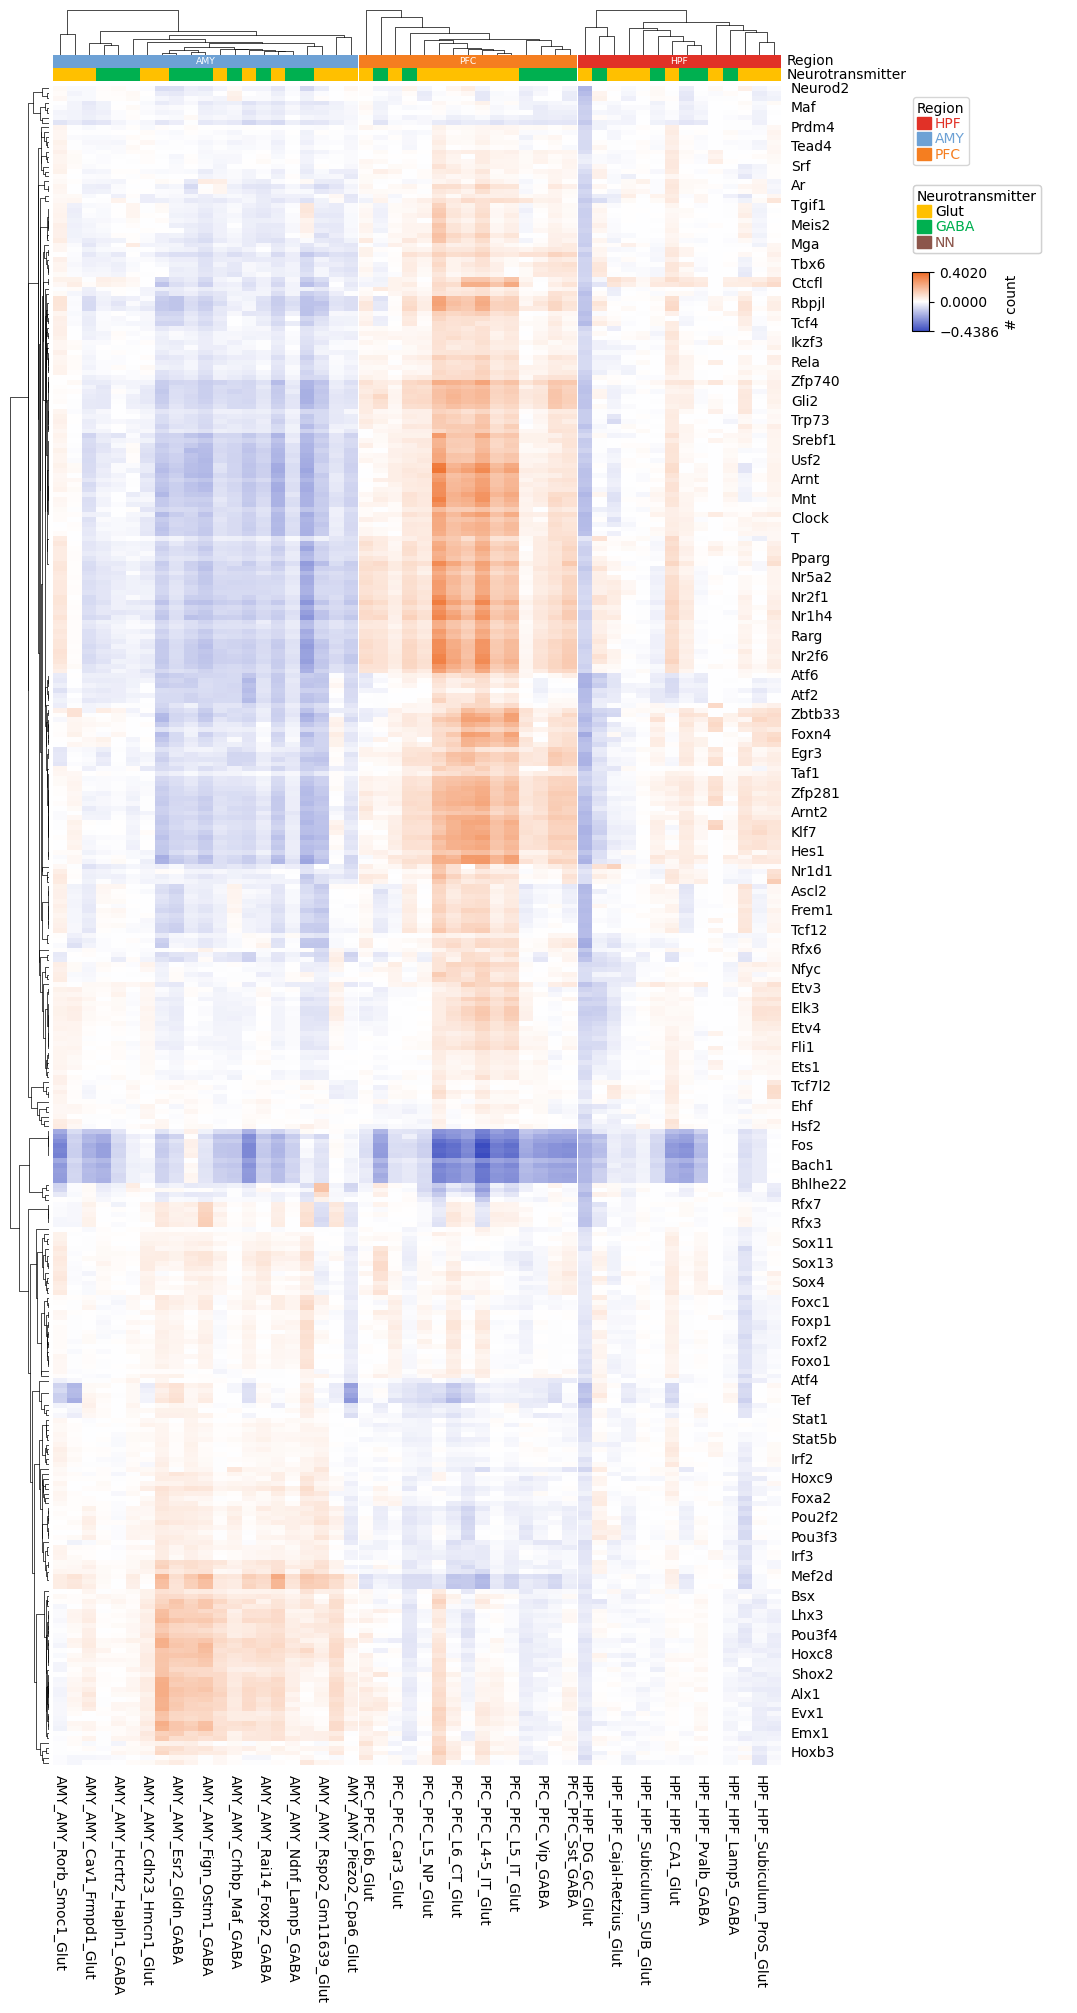

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PyComplexHeatmap as pch
from matplotlib.colors import LinearSegmentedColormap


# ---------------------------------------------------------
# 你的颜色
# ---------------------------------------------------------
region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    "PFC": "#F57E20",
}

nt_colors = {
    "Glut": "#FFC000",
    "GABA": "#00B050",
    "NN":   "#8c564b",
}


# ---------------------------------------------------------
# 主函数：绘制 TF × Region Subclass 热图
# ---------------------------------------------------------
def draw_tf_heatmap(df,value_col="Regulation", clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  

    if col_order is not None:
    # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]

    # Apply custom TF/row order if provided
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]

    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index="TF",
        columns="Region Subclass",
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)


    mat = df.pivot_table(
    index="TF",
    columns="Region Subclass",
    values=value_col,
    aggfunc="mean"
    )   

    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    # 1. Remove constant columns
    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]

    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )

    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )

    vmin = np.nanmin(mat.values)
    vmax = np.nanmax(mat.values)
    plt.figure(figsize=(10, 20))
    
    # print("Any NaN in columns? ", mat.isna().any())
    # print("Any inf? ", np.isinf(mat).any())

    # # 找出哪个 column 有 NaN / inf
    # print("Columns with NaN: ", mat.columns[mat.isna().any()].tolist())
    # print("Columns with inf: ", mat.columns[np.isinf(mat).any()].tolist())
    # ============================
    # 7. 绘制 Complex Heatmap
    # ============================
    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=True,
        col_cluster=True,
        row_dendrogram=True,
        col_dendrogram=True,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        # col_order=col_order,        # pass user-defined order
        # row_order=row_order,        # pass user-defined order
        # col_cluster=False if col_order is not None else True,
        # row_cluster=False if row_order is not None else True,

        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )

    # # # 调整字体
    # if cm.ax_col_names is not None:
    #     for txt in cm.ax_col_names.texts:
    #         txt.set_rotation(90)
    #         txt.set_fontsize(7)

    # for txt in cm.ax_heatmap.get_yticklabels():
    #     txt.set_fontsize(6)

    # # 调整列名字体
    # for txt in cm.ax_heatmap.get_xticklabels():
    #     txt.set_fontsize(7)
    #     txt.set_rotation(90)


    plt.show()
    return cm
cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC", clipping=30)

In [56]:
cm.data2d

Region Subclass,AMY_AMY_Cav1_Frmpd1_Glut,AMY_AMY_Zfhx4_Pde7b_GABA,AMY_AMY_Zfhx3_Glra1_Glut,AMY_AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Trabd2b_Coch_Glut,AMY_AMY_Tcf7l2_Gm20713_Glut,AMY_AMY_Rspo2_Gm11639_Glut,AMY_AMY_Rorb_Smoc1_Glut,AMY_AMY_Piezo2_Cpa6_Glut,AMY_AMY_Npas1_Rgs12_GABA,...,PFC_PFC_L6_IT_Glut,PFC_PFC_L5_IT_Glut,PFC_PFC_L5_NP_Glut,PFC_PFC_L5_ET_Glut,PFC_PFC_L4-5_IT_Glut,PFC_PFC_L2-3_IT_Glut,PFC_PFC_Car3_Glut,PFC_PFC_Sst_GABA,PFC_PFC_L6_CT_Glut,PFC_PFC_Vip_GABA
TF,,,,,,,,,,,,,,,,,,,,,
Alx1,0.068990,0.002790,0.128520,0.114790,0.109630,0.104180,0.037460,-0.028790,0.043340,0.000000,...,0.028600,0.007960,-0.002920,-0.032350,0.028800,0.105780,0.007440,0.044490,0.026260,-0.018230
Alx4,0.047880,0.007180,0.107215,0.106015,0.103435,0.088925,0.028695,-0.024535,0.047325,-0.003530,...,0.034920,0.007945,0.000000,-0.027165,0.025565,0.097765,0.009095,0.033035,0.038880,-0.015265
Ar,-0.038317,-0.052160,0.027730,-0.054433,-0.062480,-0.062673,-0.089757,0.030963,-0.026853,-0.041483,...,0.078860,0.075500,0.006350,0.065443,0.130217,0.097447,0.020993,0.041147,0.094253,0.009687
Arid3a,0.028970,0.052430,0.071920,0.082030,0.057580,0.036530,0.083960,0.017590,-0.005730,0.008590,...,-0.018710,-0.042020,-0.035500,-0.064890,-0.045700,0.008860,-0.011120,-0.016050,-0.071110,-0.012560
Arnt,-0.059553,-0.173057,-0.069267,-0.168603,-0.116590,-0.048977,-0.114327,0.026060,-0.095173,-0.028987,...,0.178250,0.212467,0.061403,0.224177,0.275073,0.299893,0.048330,0.081950,0.198377,0.053080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp143,-0.017070,-0.106605,-0.034655,-0.070250,-0.050885,-0.016225,-0.065760,0.034380,-0.030845,-0.008995,...,0.074150,0.095005,0.026675,0.106485,0.130210,0.112775,0.000000,0.060330,0.094295,0.027725
Zfp281,-0.022410,-0.163360,-0.077423,-0.118397,-0.078590,-0.004820,-0.132547,0.007133,-0.056863,-0.028423,...,0.144440,0.182657,0.102850,0.209177,0.239123,0.196083,0.039720,0.146807,0.212783,0.101487
Zfp740,-0.047883,-0.179593,-0.107083,-0.161057,-0.102140,-0.044567,-0.143910,0.001647,-0.074863,-0.044960,...,0.151697,0.180523,0.123887,0.207947,0.265400,0.237153,0.044950,0.156717,0.222153,0.111630


In [57]:
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)

In [58]:
row_names

['Neurod2',
 'Tcf21',
 'Twist1',
 'Mafa',
 'Maf',
 'Mafb',
 'Maff',
 'Mafk',
 'Prdm4',
 'Nfat5',
 'Tead1',
 'Tead2',
 'Tead4',
 'Bcl6',
 'Spi1',
 'Spib',
 'Srf',
 'Bcl11b',
 'Pax4',
 'Nr3c1',
 'Ar',
 'Pgr',
 'Irf5',
 'Irf6',
 'Tgif1',
 'Snai1',
 'Tgif2',
 'Meis1',
 'Meis2',
 'Meis3',
 'Pknox1',
 'Pknox2',
 'Mga',
 'Tbx2',
 'Tbx5',
 'Tbx21',
 'Tbx6',
 'Eomes',
 'Tbx20',
 'Ctcf',
 'Ctcfl',
 'Xbp1',
 'Hic1',
 'Zeb1',
 'Rbpjl',
 'Snai2',
 'Nhlh1',
 'Tcf3',
 'Tcf4',
 'Hand1',
 'Runx1',
 'Runx2',
 'Ikzf3',
 'Rel',
 'Yy1',
 'Nfkb1',
 'Rela',
 'Thap11',
 'Zfp143',
 'Ep300',
 'Zfp740',
 'Zic3',
 'Zic1',
 'Gli1',
 'Gli2',
 'Gli3',
 'Smad4',
 'Trp53',
 'Trp73',
 'Rest',
 'Runx3',
 'Srebf2',
 'Srebf1',
 'Mitf',
 'Tfe3',
 'Usf1',
 'Usf2',
 'Bhlhe40',
 'Bhlhe41',
 'Tfec',
 'Arnt',
 'Arntl',
 'Mlx',
 'Hes5',
 'Mnt',
 'Npas2',
 'Creb3l2',
 'Hey2',
 'Clock',
 'Mycn',
 'Max',
 'Myc',
 'T',
 'Nr1h3',
 'Thra',
 'Thrb',
 'Pparg',
 'Rorb',
 'Nr5a1',
 'Nr6a1',
 'Nr5a2',
 'Esrrb',
 'Esrra',
 'Esrrg',
 'Nr2f1'

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


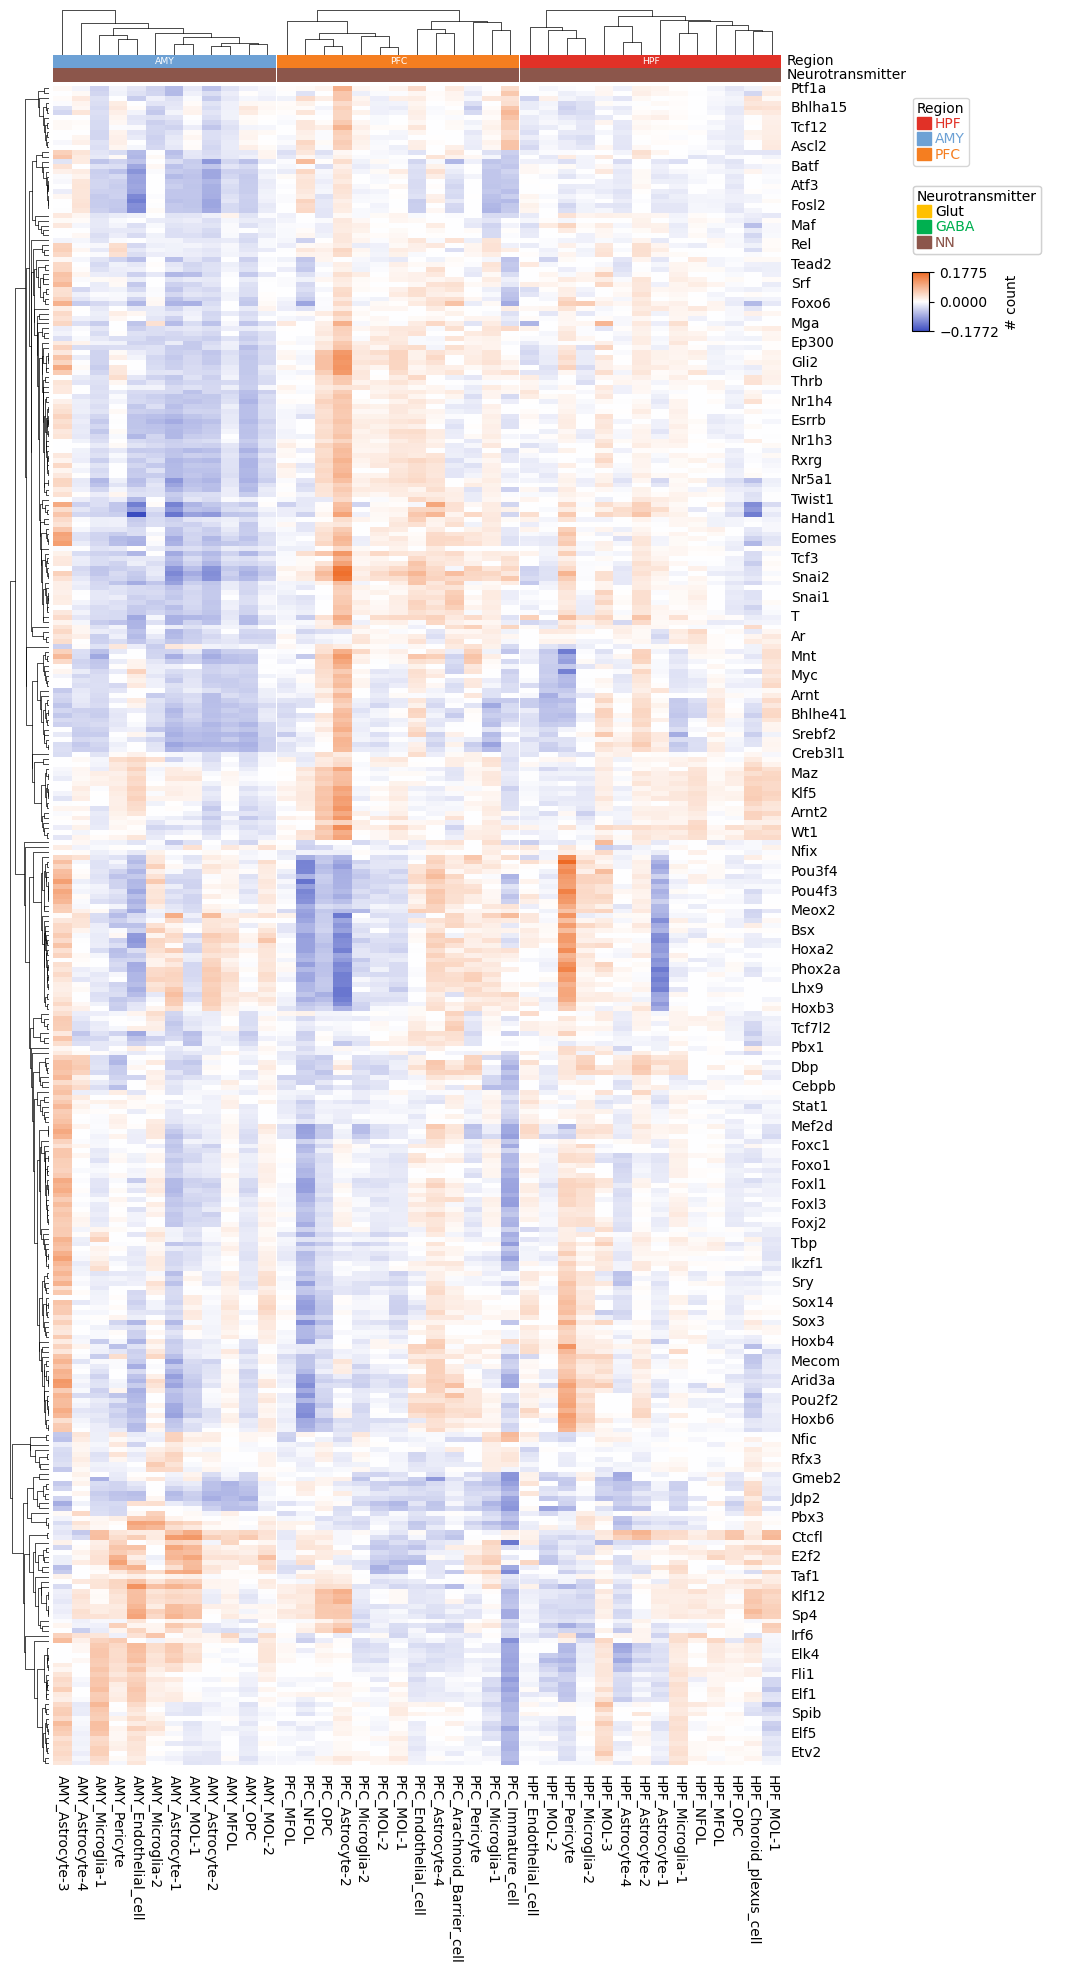

In [59]:
cm = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC")

In [60]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

/tmp/ipykernel_3593175/2779743695.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['Region Subclass'] = df_3R['Region subclass']
/tmp/ipykernel_3593175/2779743695.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
/tmp/ipykernel_3593175/2779743695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


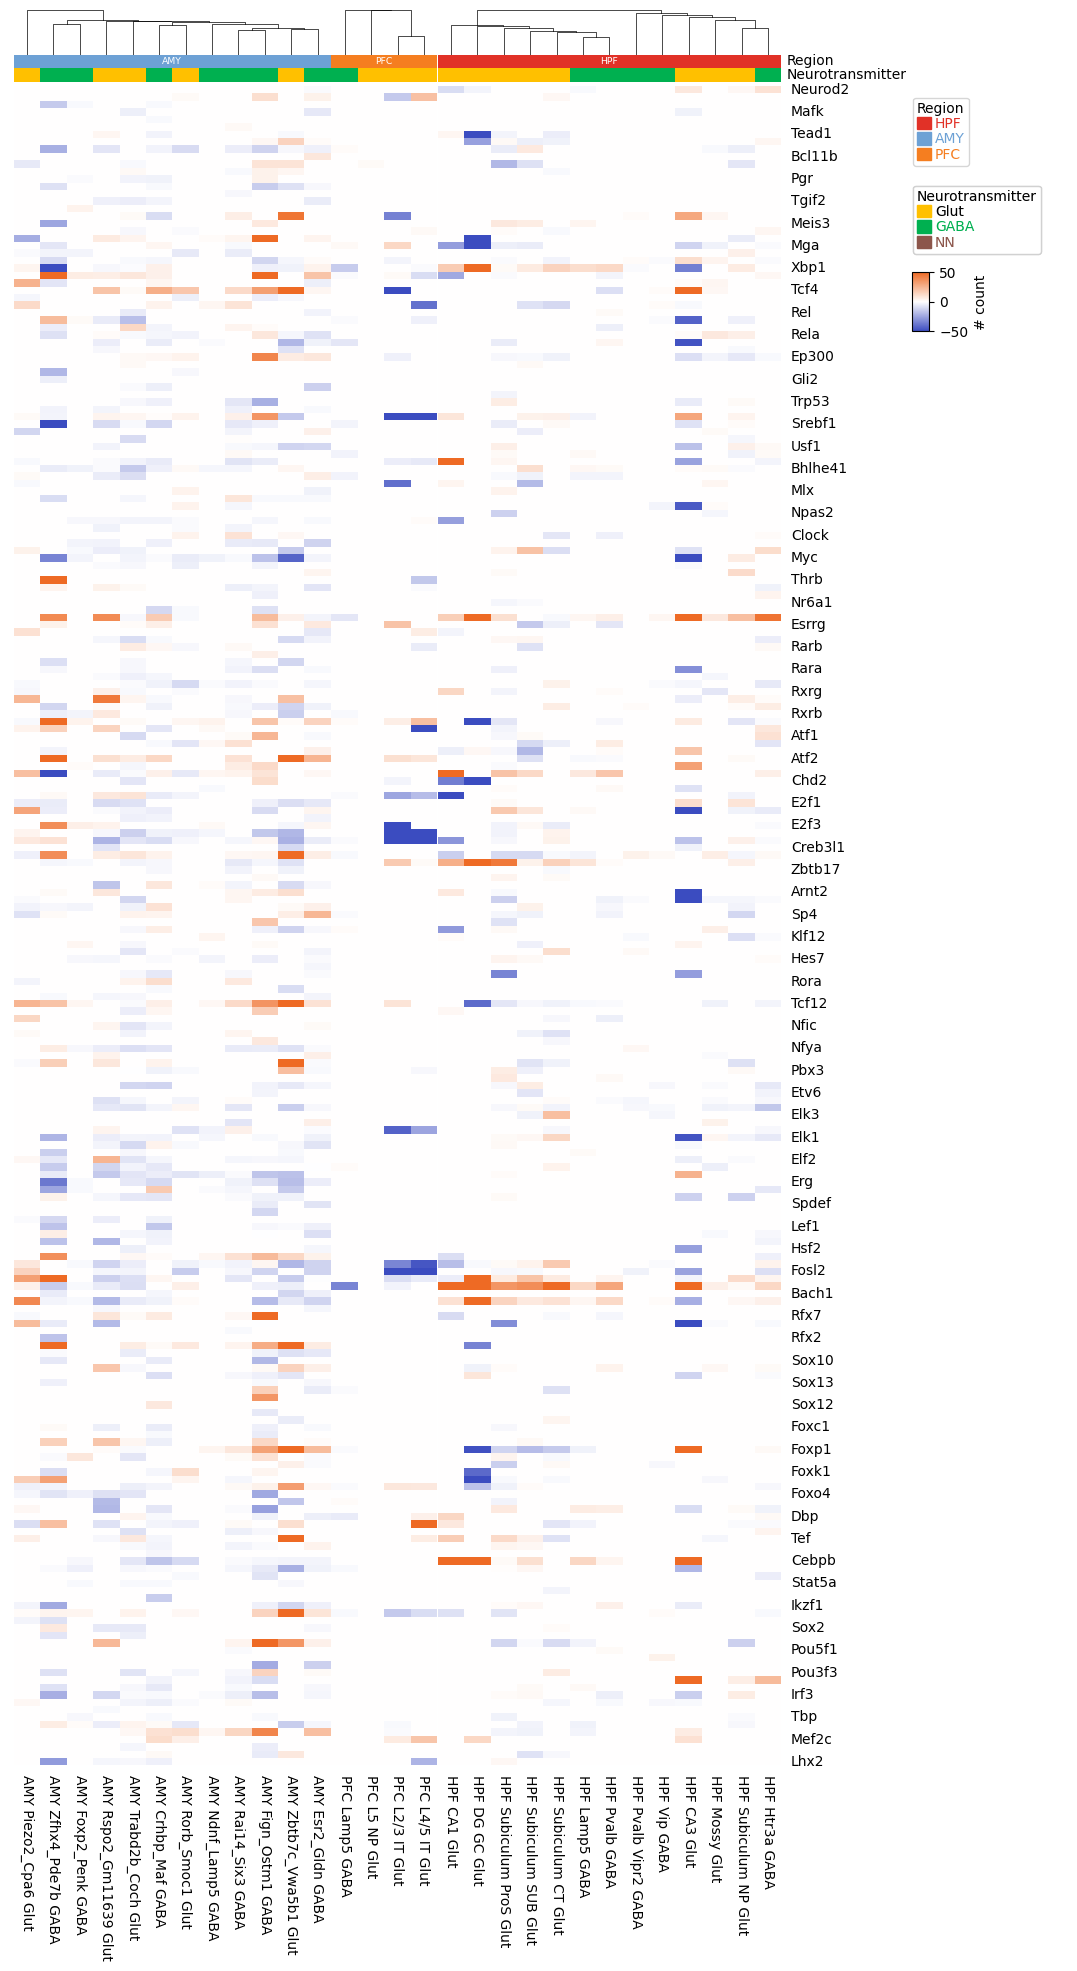

In [74]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 20))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=50)

In [62]:
df_3R

,TF,scores,log2FC,pval,FDR,pct_nz_group,pct_nz_reference,comparison,Subclass,Region,Sex,Neurotransmitter,Direction,Gene,Gene_name,Ensemble,Region subclass,Region Subclass,nlogp
5,Ets2,17.452005,0.623999,3.323606e-68,9.505513e-66,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Ets2(+),Ets2(+),Ets2(+),AMY MOL-2,AMY MOL-2,65.022024
6,Bmyc,13.413092,0.407593,5.068100e-41,2.415794e-39,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Bmyc(+),Bmyc(+),Bmyc(+),AMY MOL-2,AMY MOL-2,38.616940
7,Thra,10.567341,1.511824,4.222970e-26,1.097972e-24,0.665644,0.347495,CUSUS,MOL-2,AMY,F,NN,Up,Thra(+),Thra(+),Thra(+),AMY MOL-2,AMY MOL-2,23.959409
8,Klf10,10.401607,0.548061,2.437869e-25,5.810254e-24,0.996933,0.998911,CUSUS,MOL-2,AMY,F,NN,Up,Klf10(+),Klf10(+),Klf10(+),AMY MOL-2,AMY MOL-2,23.235805
9,Gtf2f1,9.123649,0.295695,7.263701e-20,1.598014e-18,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Gtf2f1(+),Gtf2f1(+),Gtf2f1(+),AMY MOL-2,AMY MOL-2,17.796419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11018,Foxp1,-9.354158,-0.227279,8.426752e-21,2.131968e-19,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Foxp1(+),Foxp1(+),Foxp1(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-18.671219
11019,Arntl,-9.456558,-0.183556,3.182468e-21,8.946271e-20,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Arntl(+),Arntl(+),Arntl(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-19.048358
11020,Jdp2,-9.679680,-0.312057,3.678647e-22,1.329568e-20,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Jdp2(+),Jdp2(+),Jdp2(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-19.876289
11021,Zmiz1,-9.750012,-0.134844,1.844460e-22,7.777471e-21,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Zmiz1(+),Zmiz1(+),Zmiz1(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-20.109162


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


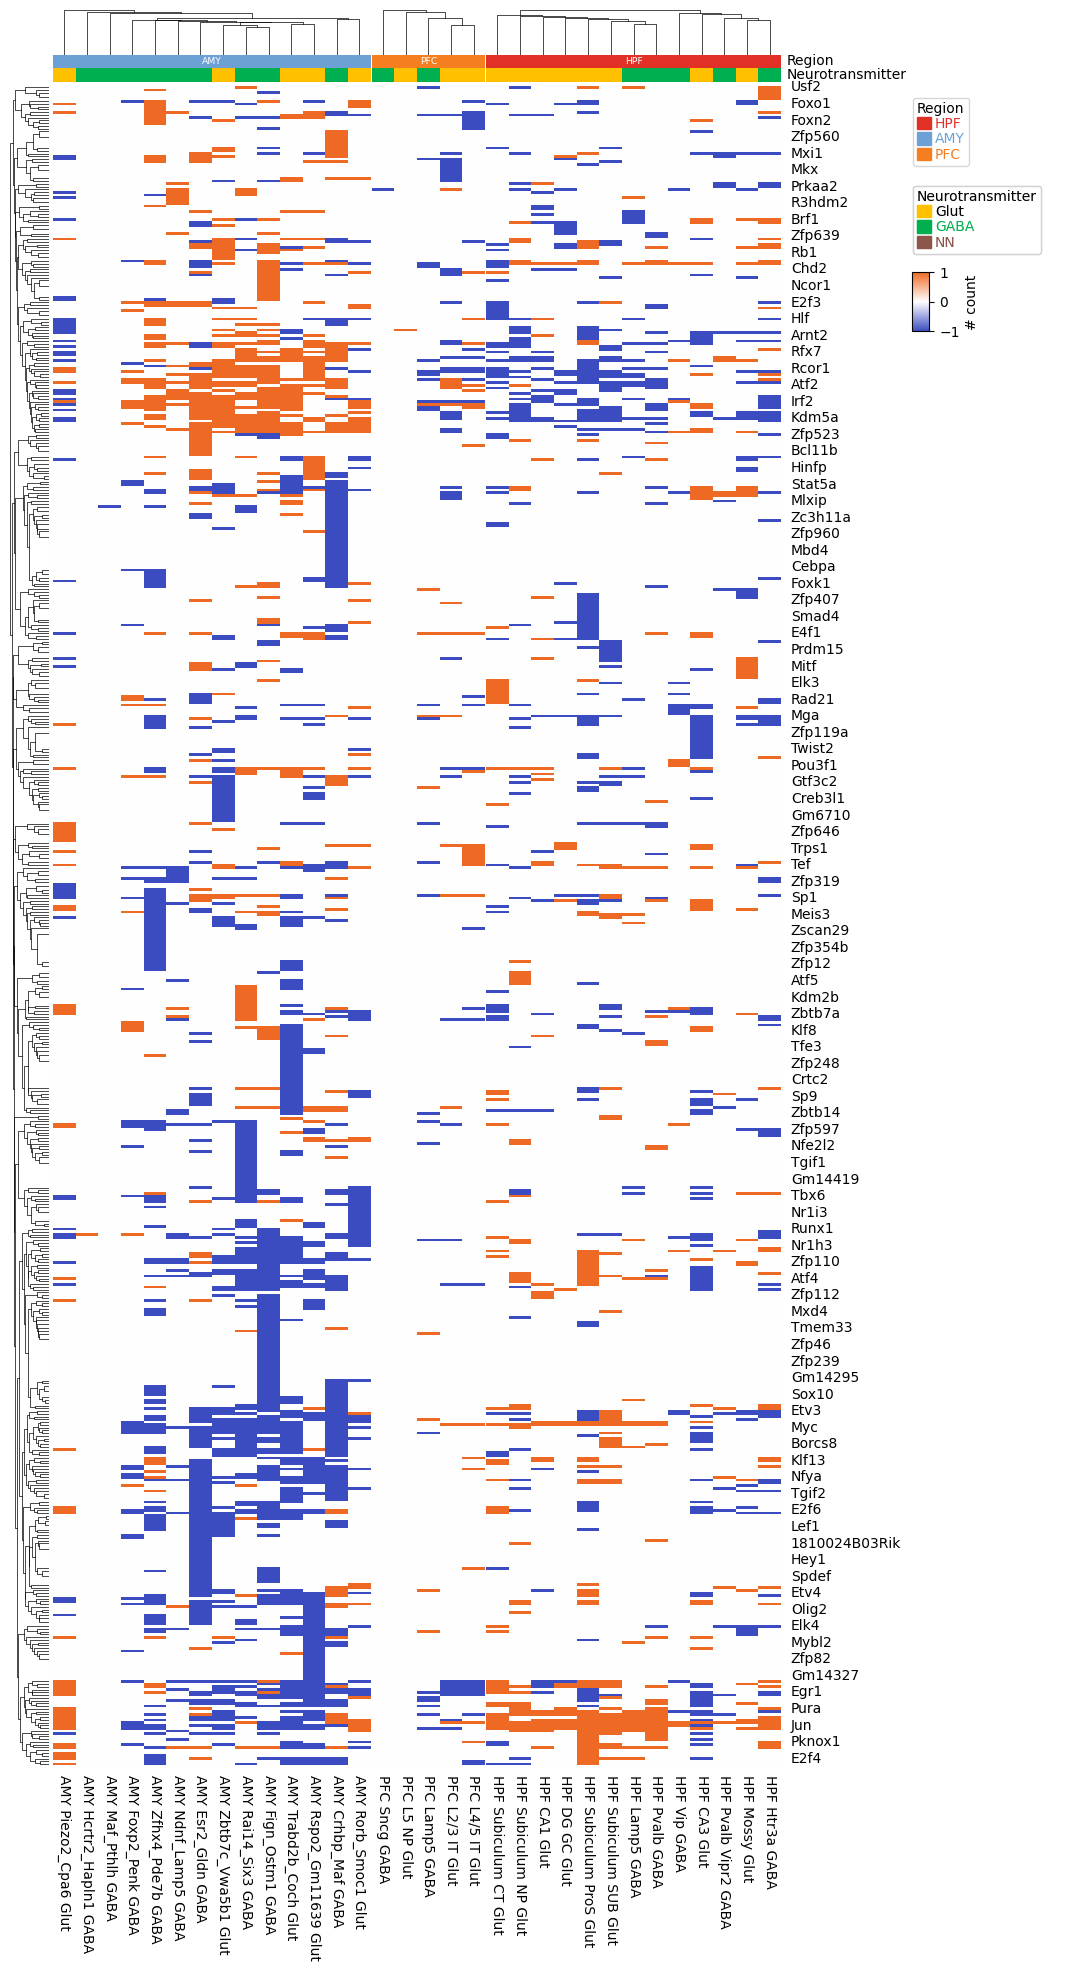

In [64]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
